# Computer Lab 4: Modeling El Niño-Southern Oscillation
This notebook will contain the entirety of the El Niño-Southern Oscillation computer lab.

## Setup
For this assignment, we will need `matplotlib.pyplot`, `numpy`, and `scipy.integrate`, as per usual. We will also need `sympy` again.

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate as integrate
import sympy

## Section 1: Equilibrium Solutions to the ENSO Model
We begin by looking at equilibrium solutions, as detailed in class.

### Part 1.1
Here, we are asked to seek steady-state solutions to the Vallis ENSO model. Recall that this model, in its simplest form, gives us three equations governing the zonal dynamics of the Pacific as

$$ \frac{d}{dt}U = B(T_E-T_W) + C(U_0-U) $$
$$ \frac{d}{dt}T_E = \frac{U}{\Delta x}T_W + A(T_0-T_E) $$
$$ \frac{d}{dt}T_W = \frac{-U}{\Delta x}T_E + A(T_0-T_W) $$

To find our steady-state solution, we set all of these derivatives equal to zero, and solve. Let's begin with the case where $U_0=-0.5\mathrm{ms}^{-1}$ and $B=1.3\times10^{-7}\mathrm{ms}^{-2}\degree\mathrm{C}^{-1}$. We are also given that $\Delta x = 7500\mathrm{km} = 7.5\times10^6\mathrm{m}$, $T_0=-15\degree\mathrm{C}$, $A = (6\;\mathrm{months})^{-1}$, and $C=(2\;\mathrm{months})^{-1}$. Let's quickly convert $A$ and $C$ to seconds by finding the average number of seconds in a month.

In [37]:
# Year = 365.2425 days x 24 hours x 60 minutes x 60 seconds
sec_year = 365.2425 * 24 * 60 * 60
A = 1 / (6 / 12 * sec_year)
C = 1 / (2 / 12 * sec_year)
print(A, C)

6.337747701362287e-08 1.9013243104086862e-07


We find that $A=6.338\times10^{-8}\mathrm{s}^{-1}$ and $C=1.901\times10^{-7}\mathrm{s}^{-1}$. With that, let's set up our first case and solve.

In [92]:
del_x = 7.5 * 10**6
T_0 = 15
U_0 = -0.5
B = 1.3 * 10**(-7)

T_e, T_w, U = sympy.symbols("T_e T_w U")

eq1 = sympy.Eq(B * (T_e - T_w) + C * (U_0 - U), 0)
eq2 = sympy.Eq(U / del_x * T_w + A * (T_0 - T_e), 0)
eq3 = sympy.Eq(-U / del_x * T_e + A * (T_0 - T_w), 0)

slns = sympy.nonlinsolve([eq1, eq2, eq3], [T_e, T_w, U])
[T_e_sln for T_e_sln, T_w_sln, U_sln in slns]


[-1.78960994679588, 2.85111529819720, 15.3649721013234]

In [57]:
num = 1
for T_e_sln, T_w_sln, U_sln in slns:
    print("Sln. #" + str(num) + "\n",
    "U = " + str(round(U_sln, 4)) + " m/s\n",
    "T_e = " + str(round(T_e_sln, 4)) + " degC\n",
    "T_w = " + str(round(T_w_sln, 4)) + " degC\n",
    "Resid. for eq1, eq2, eq3: ",
    round(B * (T_e_sln - T_w_sln) + C * (U_0 - U_sln), 4), 
    round(U_sln / del_x * T_w_sln + A * (T_0 - T_e_sln), 4), 
    round(-1 * U_sln / del_x * T_e_sln + A * (T_0 - T_w_sln), 4))
    num += 1


Sln. #1
 U = -3.3517 m/s
 T_e = -1.7896 degC
 T_w = 2.3811 degC
 Resid. for eq1, eq2, eq3:  0.0 0.0 0.0
Sln. #2
 U = 2.8398 m/s
 T_e = 2.8511 degC
 T_w = -2.0335 degC
 Resid. for eq1, eq2, eq3:  0.0 0.0 0.0
Sln. #3
 U = 0.0119 m/s
 T_e = 15.3650 degC
 T_w = 14.6163 degC
 Resid. for eq1, eq2, eq3:  0 0.0 0.0


We find three real solutions, and for each solution, we have reached equilibrium with Vallis' state equations. This means our next step is to repeat this process for the next two cases, now allowing $B$ to vary.

In [148]:
# Define new variables
B_range = np.linspace(10**(-9), 10**(-6))
U_0 = 0

# Loop through possible values of B
T_diff = np.array([0, 0])
for B in B_range:

    # Set up equations
    eq1 = sympy.Eq(B * (T_e - T_w) + C * (U_0 - U), 0)
    eq2 = sympy.Eq(U / del_x * T_w + A * (T_0 - T_e), 0)
    eq3 = sympy.Eq(-U / del_x * T_e + A * (T_0 - T_w), 0)

    # Solve and isolate solutions
    solved = sympy.nonlinsolve([eq1, eq2, eq3], [T_e, T_w, U])
    slns = np.array([(T_e_sln, T_w_sln, U_sln) for T_e_sln, T_w_sln, U_sln in solved])

    # Determine which solutions are real and filter
    real_sln = np.array([all([T_e_sln.is_real, T_w_sln.is_real, U_sln.is_real]) for T_e_sln, T_w_sln, U_sln in solved])
    num_real_sln = int(slns[real_sln].size / 3)

    # Collect temperature differences
    for sln in slns[real_sln]:
        
        # T_w - T_e
        T_diff = np.vstack([T_diff, np.array([B, sln[1] - sln[0]])])

# Delete first row (it was a filler row)
T_diff = np.delete(T_diff, (0), axis = 0)

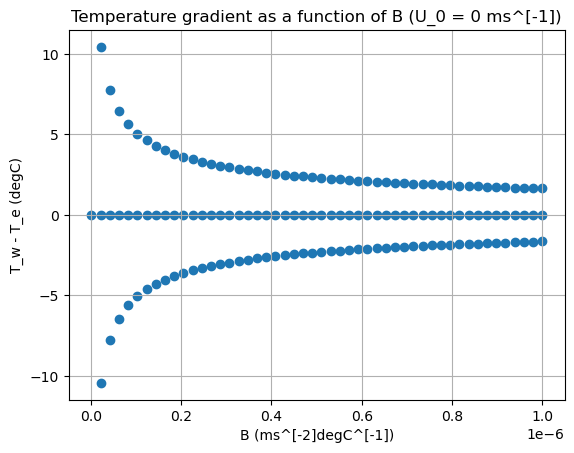

In [149]:
# Set up plot
fig, ax = plt.subplots()

# Plot data and label
ax.scatter(T_diff[:,0], T_diff[:,1])
ax.set_title("Temperature gradient as a function of B (U_0 = 0 ms^[-1])")
ax.set_ylabel("T_w - T_e (degC)")
ax.set_xlabel("B (ms^[-2]degC^[-1])")
ax.grid()

As $B$ increases, we see that one of the solutions stays consistently at a $0\degree\mathrm{C}$ temperature gradient, and the other two --- symmetrically around the $0\degree\mathrm{C}$-axis --- approach the midpoint from what seem to be $+\infty$ and $-\infty$. Let's do the same analysis with $U_0=-0.5\mathrm{ms}^{-1}$.

In [150]:
# Define new variables
U_0 = -0.5

# Loop through possible values of B
T_diff = np.array([0, 0])
for B in B_range:

    # Set up equations
    eq1 = sympy.Eq(B * (T_e - T_w) + C * (U_0 - U), 0)
    eq2 = sympy.Eq(U / del_x * T_w + A * (T_0 - T_e), 0)
    eq3 = sympy.Eq(-U / del_x * T_e + A * (T_0 - T_w), 0)

    # Solve and isolate solutions
    solved = sympy.nonlinsolve([eq1, eq2, eq3], [T_e, T_w, U])
    slns = np.array([(T_e_sln, T_w_sln, U_sln) for T_e_sln, T_w_sln, U_sln in solved])

    # Determine which solutions are real and filter
    real_sln = np.array([all([T_e_sln.is_real, T_w_sln.is_real, U_sln.is_real]) for T_e_sln, T_w_sln, U_sln in solved])
    num_real_sln = int(slns[real_sln].size / 3)

    # Collect temperature differences
    for sln in slns[real_sln]:
        
        # T_w - T_e
        T_diff = np.vstack([T_diff, np.array([B, sln[1] - sln[0]])])

# Delete first row (it was a filler row)
T_diff = np.delete(T_diff, (0), axis = 0)

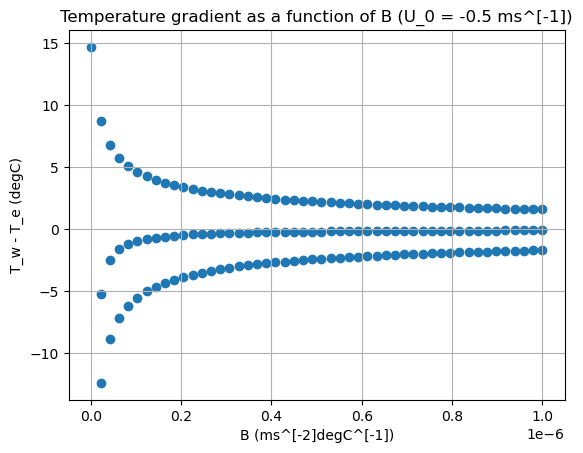

In [151]:
# Set up plot
fig, ax = plt.subplots()

# Plot data and label
ax.scatter(T_diff[:,0], T_diff[:,1])
ax.set_title("Temperature gradient as a function of B (U_0 = -0.5 ms^[-1])")
ax.set_ylabel("T_w - T_e (degC)")
ax.set_xlabel("B (ms^[-2]degC^[-1])")
ax.grid()

This case seems very similar to the prior, except now the "middle solution" also approaches $0\degree\mathrm{C}$ from $-\infty$. This makes sense; slight differences in initial conditions may change the behavior of our system dramatically in some regimes, but the asymptotic temperature gradient as $B$ increases seems to remain relatively invariant under the conditions we've tested.